In [ ]:
# 13th April, 2026
# Ollama support in llamaindex
# Examples

In [20]:
# 1.0 Call libraries
from llama_index.llms.ollama import Ollama
from llama_index.core import Settings


In [21]:
# 1.1 Configure the model
llm = Ollama(model="llama3.2:1b",
             request_timeout=120.0,
             temperature = 0.9
            )

In [22]:
# 1.3 Optional: Set as default LLM for LlamaIndex
Settings.llm = llm

# 1.4 Generate a response
response = llm.complete("What is LlamaIndex?")
print(response)

I'm not familiar with a specific entity called "LlamaIndex." It's possible that it's a relatively new or lesser-known term, or it could be a misspelling or variation of another term.

Could you please provide more context or information about what you mean by "LlamaIndex"? What does it seem to be related to?


In [4]:
response = llm.complete("Tell me about Delhi's history")
print(response)

Delhi, the capital city of India, has a rich and diverse history spanning over 2,000 years. It is situated on the Yamuna River and is bounded by the Yamuna to the west, Hauz Khas to the south, Chandni Chowk to the north, and Qutub Minar to the east.

**Ancient Period (330 BCE - 1200 CE)**

Delhi's history began with the Indus Valley Civilization around 330 BCE. The city was later ruled by the Mauryan Empire under Chandragupta Maurya in the 3rd century BCE. After the fall of the Mauryan Empire, Delhi was invaded by various empires and dynasties, including the Kushans, Gupta, and Rashtrakutas.

**Gupta Era (320 - 550 CE)**

The Gupta period marked a golden age for Delhi. The city became a major center of trade, culture, and learning. Emperor Ashoka, who ruled from 269 to 232 BCE, was particularly fond of Delhi and built several temples and monuments in the city.

**Islamic Rule (1206 - 1526 CE)**

In 1206 CE, Delhi was captured by Muslim ruler Qutub-ud-Din Aibak. He established a Muslim 

In [5]:
response = llm.complete("Tell me more about the period 1989 CE - present")
print(response)

Here's an overview of the period from 1989 to the present:

**1989-1991: The End of the Cold War and Rise of Globalization**

* The fall of the Berlin Wall in November 1989 marked a significant turning point, symbolizing the end of the Cold War.
* In 1990, the Soviet Union dissolved, and Russia became an independent country.
* The International Monetary Fund (IMF) implemented policies to help emerging markets recover from the economic downturn of the 1970s and early 1980s.
* Globalization began to take shape, with international trade increasing and globalization being driven by technological advancements.

**1992-2001: Economic Downturn and Rise of Nationalism**

* The Asian financial crisis in 1997 led to a global economic downturn, affecting economies such as Thailand, Indonesia, and South Korea.
* In the early 2000s, the United States experienced a recession, followed by a period of slow growth.
* The rise of nationalism, particularly in Europe and the United States, marked a shift 

## Multi-turn conversation

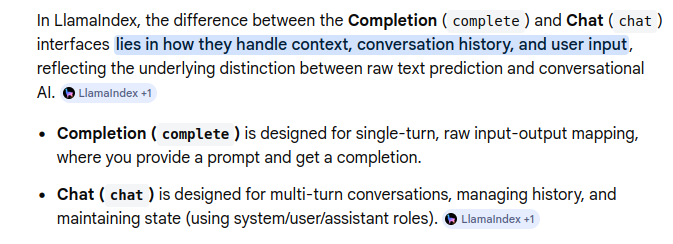

In [23]:
# 2.0
from llama_index.core.llms import ChatMessage

# 2.1
messages = [
            ChatMessage(role="system", content="You are a helpful assistant."),
            ChatMessage(role="user", content="Tell me about Delhi's history"),
           ]
# 2.2
chat_response = llm.chat(messages)
print(chat_response)

assistant: Delhi, the capital city of India, has a rich and diverse history that spans over 2,000 years. It is a city that has been ruled by various empires and dynasties, including the Indus Valley Civilization, the Mauryan Empire, the Gupta Empire, the Mughal Empire, and the British East India Company.

**Indus Valley Civilization (2500 BCE - 1300 BCE)**

The earliest known civilization in Delhi is the Indus Valley Civilization, which flourished around 2500 BCE. This civilization was a Bronze Age culture that traded with neighboring cities in the region. The city of Mohenjo-Daro, located nearby, is one of the most famous archaeological sites in India.

**Mauryan Empire (322 BCE - 185 BCE)**

In 322 BCE, the Mauryan Empire was founded by Chandragupta Maurya, who conquered the Indus Valley Civilization and established a vast empire that stretched from modern-day Afghanistan to Bangladesh. The capital of the Mauryan Empire was Pataliputra, which is now Patna in Bihar.

**Gupta Empire (3

In [11]:
# 3.0
# Ask more questions on answer to first
chat_response = llm.chat([ChatMessage(role="user", content="Tell me more about the period 1857-1947 CE")])
print(chat_response)

assistant: The period of 1857-1947 CE, also known as the British Raj or Colonial Era in India, was a significant time for both the British Empire and the Indian subcontinent. Here's an overview:

**British East India Company (EIC) Rule (1857-1885)**

After the Indian Rebellion of 1857, also known as the Sepoy Mutiny, the EIC was granted a royal charter by Queen Victoria to govern India. The company's power grew rapidly, and it eventually became a full-fledged British colony in 1876.

During this period:

* The EIC introduced modern infrastructure, such as railways, roads, and canals.
* Indian taxes were increased, leading to widespread resentment among the Indian population.
* The British government implemented policies aimed at strengthening its control over India's economy, including the Land Alienation Act of 1855, which allowed for the confiscation of land from native Indians.

**British Raj (1885-1947)**

After the EIC's dissolution in 1874, the British government established a fo

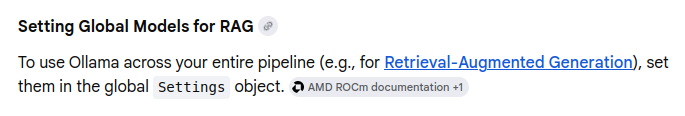

In [24]:
# 4.0
from llama_index.core import Settings
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding

# 4.1 Global LLM
Settings.llm = Ollama(model="llama3.1:8b", request_timeout=120.0)

# 4.2 Global Embedding Model
Settings.embed_model = OllamaEmbedding(model_name="nomic-embed-text")


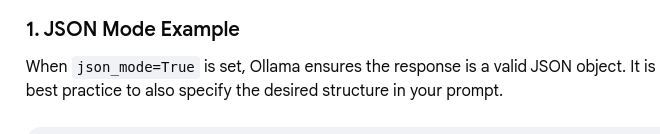

In [13]:
# 5.0
from llama_index.llms.ollama import Ollama

# 5.1 Initialize LLM with JSON mode enabled
llm = Ollama(model="llama3.2:1b",
             request_timeout=120.0,
             json_mode=True)

# 5.2 The prompt should ask for a JSON structure
prompt = "Who is Paul Graham? Output as a structured JSON object with keys: 'name', 'description', and 'notable_work'."


{
  "name": "Paul Graham",
  "description": "A computer programmer, entrepreneur, and online educator.",
  "notable_work": [
    {
      "title": "Y Combinator",
      "description": "Co-founder of Y Combinator, a seed capital for startup accelerators."
    },
    {
      "title": "Free Code Camp",
      "description": "Founder of Free Code Camp, an online platform that provides free coding education to anyone."
    }
  ]
}


In [ ]:
# 5.3 Get response
response = llm.complete(prompt)
print(response.text)


## To Do

### A

In [17]:
# Use a unique key per user to keep their conversations separate
chat_store = SimpleChatStore()
memory = ChatMemoryBuffer.from_defaults(
    token_limit=3000, 
    chat_store=chat_store, 
    chat_store_key="user_123"
)

chat_engine = index.as_chat_engine(memory=memory)

NameError: name 'index' is not defined

In [ ]:
# Multimodal support in llama Index. The following example does not work.
# See this page

### B

In [15]:
from llama_index.llms.ollama import Ollama
from llama_index.core.llms import ChatMessage, ImageBlock

# Initialize the standard Ollama LLM with a vision model
llm = Ollama(model="llava:latest", request_timeout=120.0)

# Create a message with both text and an image block
messages = [
    ChatMessage(
        role="user",
        blocks=[
            ImageBlock(path="/home/ashok/Documents/llamaindex/deeplearning_course/pie-chart-movies.jpg"),
            "Describe the contents of this image."
        ]
    )
]

# Use the regular chat method
response = llm.chat(messages)
print(response.message.content)


ValidationError: 1 validation error for ChatMessage
blocks.1
  Input should be a valid dictionary or object to extract fields from [type=model_attributes_type, input_value='Describe the contents of this image.', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/model_attributes_type

In [ ]:
################## Done ##############